<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 — Algoritma Klasifikasi

Nama Lengkap: Sakti Cristopel Lingga

NIM: 240401010125

Kelas: IF403

### Topik

Logistic Regression, Decision Tree, Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score

### Dataset

Breast Cancer Wisconsin Dataset dari Scikit-Learn


# Tujuan Praktikum

Praktikum ini bertujuan untuk memahami penerapan algoritma klasifikasi menggunakan Logistic Regression dan Decision Tree pada dataset Breast Cancer Wisconsin.

Pada praktikum ini dilakukan beberapa tahapan, yaitu:

1. Memuat dan memahami dataset.
2. Melakukan Exploratory Data Analysis (EDA) sederhana.
3. Melakukan preprocessing data menggunakan Train-Test Split dan StandardScaler.
4. Melatih model Logistic Regression.
5. Melatih model Decision Tree.
6. Mengevaluasi kedua model menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.
7. Membandingkan performa Logistic Regression dan Decision Tree, terutama berdasarkan nilai Recall.


## Langkah 1 — Load Dataset

Dataset yang digunakan adalah Breast Cancer Wisconsin Dataset yang tersedia secara bawaan pada Scikit-Learn.

Dataset memiliki 569 observasi dan 30 fitur numerik yang menggambarkan karakteristik sel kanker.

Target terdiri dari dua kelas:

* `0` = Malignant (ganas)
* `1` = Benign (jinak)


In [2]:
# Import library yang diperlukan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


In [4]:
# Load dataset
data = load_breast_cancer()

# Membuat DataFrame
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\n5 data pertama:")
display(X.head())

Shape X: (569, 30)
Shape y: (569,)

5 data pertama:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Informasi dataset

print("Jumlah observasi :", X.shape[0])
print("Jumlah fitur     :", X.shape[1])

print("\nNama fitur:")
print(list(X.columns))

Jumlah observasi : 569
Jumlah fitur     : 30

Nama fitur:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


## Distribusi Target

Distribusi target digunakan untuk melihat jumlah data pada masing-masing kelas, yaitu Malignant dan Benign. Pemeriksaan ini penting untuk mengetahui apakah dataset memiliki distribusi kelas yang seimbang.


Jumlah masing-masing kelas:
0    212
1    357
Name: count, dtype: int64

Proporsi masing-masing kelas:
0    0.373
1    0.627
Name: proportion, dtype: float64


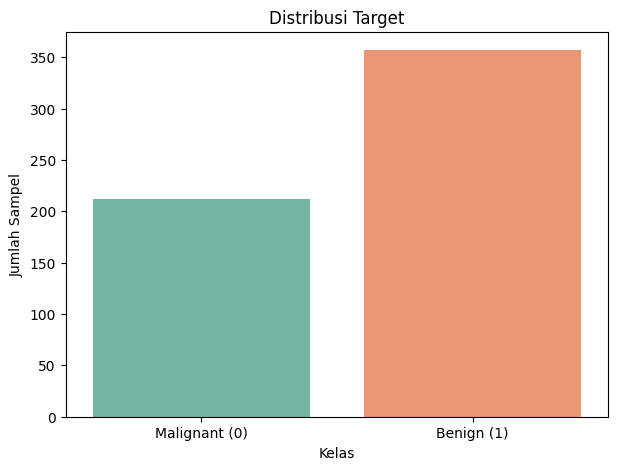

In [6]:
# Distribusi target

target_counts = pd.Series(y).value_counts().sort_index()

print("Jumlah masing-masing kelas:")
print(target_counts)

print("\nProporsi masing-masing kelas:")
print(
    pd.Series(y)
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
)

# Visualisasi
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y,
    hue=y,
    palette="Set2",
    legend=False
)

plt.xticks(
    [0, 1],
    ["Malignant (0)", "Benign (1)"]
)

plt.title("Distribusi Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.show()

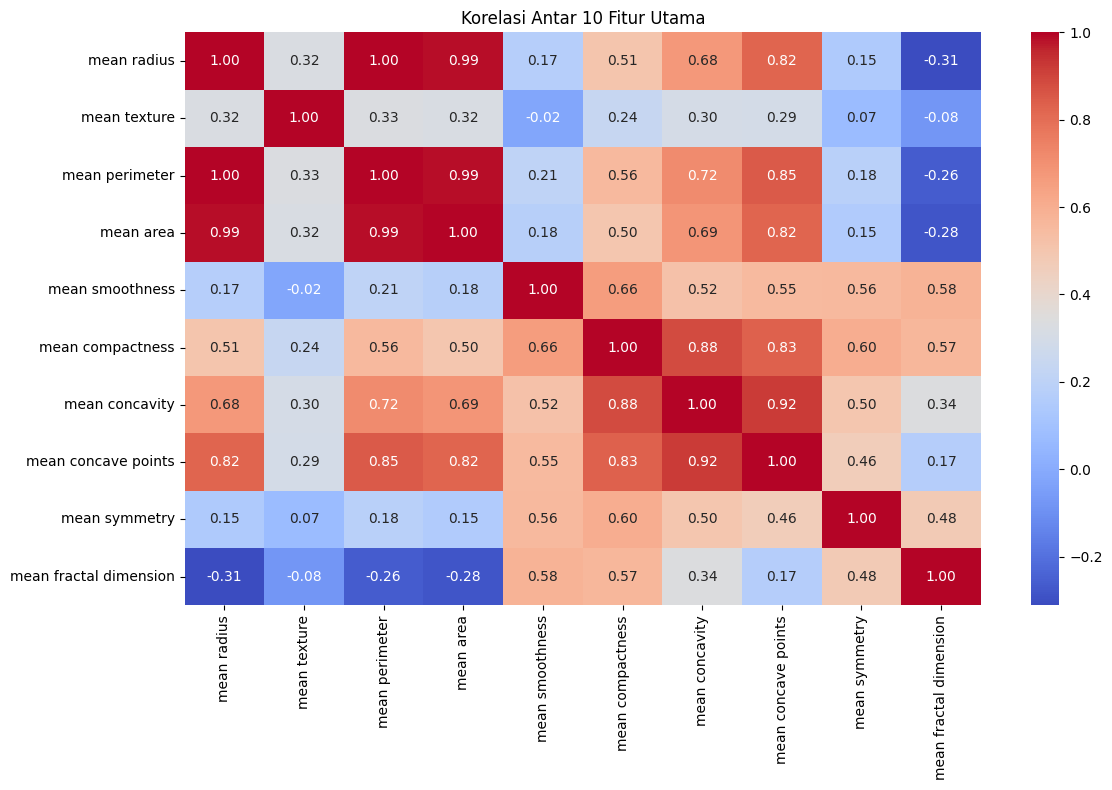

In [7]:
# Korelasi 10 fitur pertama

selected_features = X.columns[:10]

correlation = X[selected_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Korelasi Antar 10 Fitur Utama")
plt.tight_layout()
plt.show()

### Interpretasi

Heatmap menunjukkan hubungan atau korelasi antar fitur. Nilai korelasi mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai mendekati -1 menunjukkan hubungan negatif yang kuat. Korelasi yang tinggi menunjukkan bahwa beberapa fitur memiliki pola yang mirip dan dapat memberikan informasi yang saling berkaitan terhadap karakteristik sel kanker.


## Langkah 2 — Preprocessing

Dataset dibagi menjadi data training dan data testing dengan perbandingan 80:20.

Parameter `stratify=y` digunakan agar proporsi kelas Malignant dan Benign pada data training dan testing tetap relatif sama.


In [8]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

Jumlah data training : 455
Jumlah data testing  : 114


In [9]:
# Standardisasi fitur

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Standardisasi berhasil dilakukan.")
print("Ukuran X_train_s:", X_train_s.shape)
print("Ukuran X_test_s :", X_test_s.shape)

Standardisasi berhasil dilakukan.
Ukuran X_train_s: (455, 30)
Ukuran X_test_s : (114, 30)


### StandardScaler

StandardScaler digunakan untuk membuat skala setiap fitur menjadi lebih seragam dengan cara melakukan standardisasi berdasarkan nilai mean dan standar deviasi data training.

Standardisasi terutama penting untuk Logistic Regression karena model ini sensitif terhadap perbedaan skala antar fitur. Decision Tree tidak membutuhkan standardisasi karena proses pemisahan data berdasarkan nilai threshold fitur.


## Langkah 3 — Logistic Regression

Logistic Regression digunakan sebagai model klasifikasi pertama. Model dilatih menggunakan data yang telah distandarisasi.


In [10]:
# Membuat model Logistic Regression

log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Training
log_model.fit(X_train_s, y_train)

# Prediksi
y_pred_log = log_model.predict(X_test_s)

print("Logistic Regression berhasil dilatih.")

Logistic Regression berhasil dilatih.


In [11]:
# Melihat koefisien Logistic Regression

coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df["Abs_Koefisien"] = abs(coef_df["Koefisien"])

coef_df = coef_df.sort_values(
    "Abs_Koefisien",
    ascending=False
)

print("10 fitur dengan pengaruh terbesar:")
display(coef_df.head(10))

# Melihat koefisien Logistic Regression

coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df["Abs_Koefisien"] = abs(coef_df["Koefisien"])

coef_df = coef_df.sort_values(
    "Abs_Koefisien",
    ascending=False
)

print("10 fitur dengan pengaruh terbesar:")
display(coef_df.head(10))

10 fitur dengan pengaruh terbesar:


,Fitur,Koefisien,Abs_Koefisien
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


10 fitur dengan pengaruh terbesar:


,Fitur,Koefisien,Abs_Koefisien
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


### Interpretasi Koefisien

Koefisien Logistic Regression menunjukkan arah dan kekuatan hubungan fitur terhadap prediksi kelas. Nilai koefisien positif menunjukkan kecenderungan meningkatkan peluang prediksi menuju kelas Benign (1), sedangkan nilai negatif menunjukkan kecenderungan menuju kelas Malignant (0).

Fitur dengan nilai absolut koefisien yang lebih besar memiliki pengaruh relatif lebih besar terhadap keputusan model. Namun, koefisien ini harus dipahami sebagai hubungan dalam model, bukan sebagai bukti bahwa suatu fitur secara langsung menyebabkan kanker.


## Langkah 4 — Decision Tree

Model kedua yang digunakan adalah Decision Tree dengan `max_depth=4`.

Decision Tree tidak membutuhkan StandardScaler karena model melakukan pemisahan berdasarkan kondisi atau threshold pada nilai fitur.


In [13]:
# Membuat model Decision Tree

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Training
tree_model.fit(X_train, y_train)

# Prediksi
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


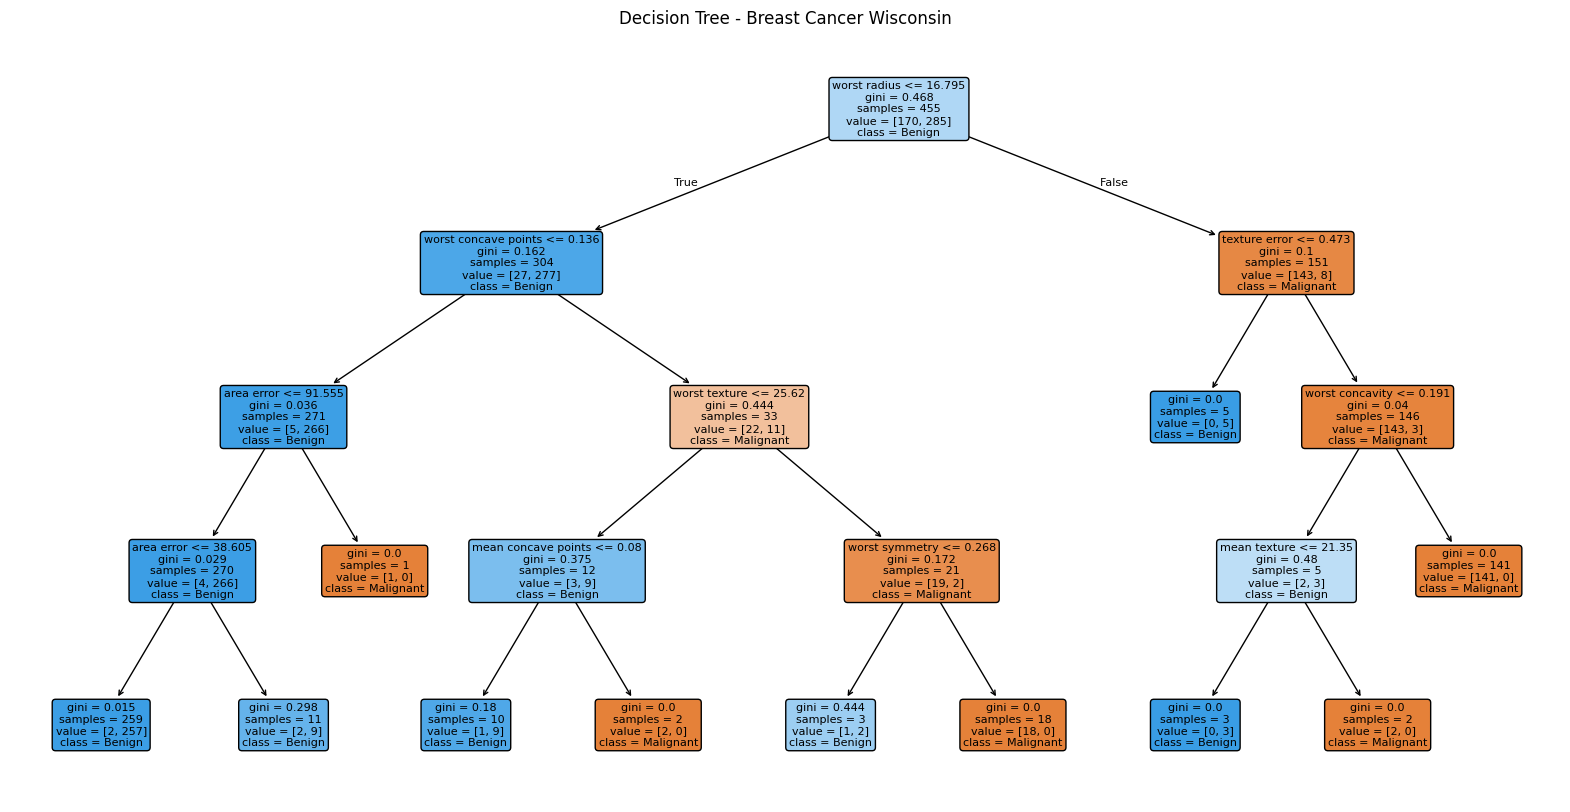

In [14]:
# Visualisasi Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Breast Cancer Wisconsin")
plt.show()

## Langkah 5 — Evaluasi Logistic Regression

Model Logistic Regression dievaluasi menggunakan empat metrik klasifikasi:

* **Accuracy**
* **Precision**
* **Recall**
* **F1-Score**

Selain itu digunakan Confusion Matrix untuk melihat jumlah prediksi benar dan salah pada masing-masing kelas.


In [16]:
# Evaluasi Logistic Regression

cm_log = confusion_matrix(y_test, y_pred_log)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("=== Logistic Regression ===")
print("\nConfusion Matrix:")
print(cm_log)

print(f"\nAccuracy : {accuracy_log:.3f}")
print(f"Precision: {precision_log:.3f}")
print(f"Recall   : {recall_log:.3f}")
print(f"F1-Score : {f1_log:.3f}")

=== Logistic Regression ===

Confusion Matrix:
[[41  1]
 [ 1 71]]

Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986


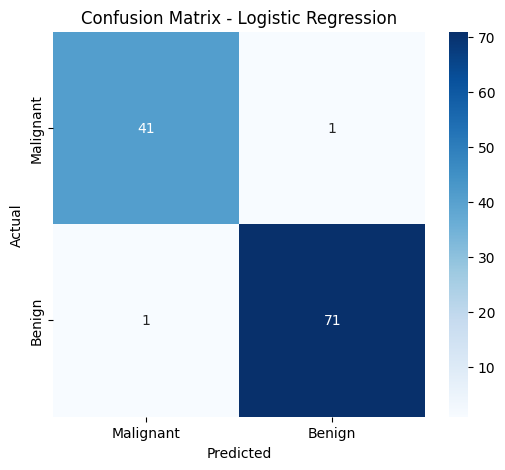

In [17]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Decision Tree ===

Confusion Matrix:
[[39  3]
 [ 4 68]]

Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


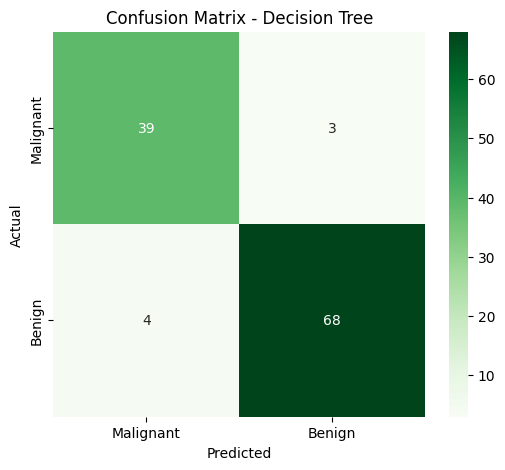

In [19]:
# Evaluasi Decision Tree

cm_tree = confusion_matrix(y_test, y_pred_tree)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("=== Decision Tree ===")
print("\nConfusion Matrix:")
print(cm_tree)

print(f"\nAccuracy : {accuracy_tree:.3f}")
print(f"Precision: {precision_tree:.3f}")
print(f"Recall   : {recall_tree:.3f}")
print(f"F1-Score : {f1_tree:.3f}")

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# Membuat tabel perbandingan model

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_tree
    ],
    "Precision": [
        precision_log,
        precision_tree
    ],
    "Recall": [
        recall_log,
        recall_tree
    ],
    "F1-Score": [
        f1_log,
        f1_tree
    ]
})

comparison = comparison.set_index("Model")

display(comparison.round(3))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.982,0.986,0.986,0.986
Decision Tree,0.939,0.958,0.944,0.951


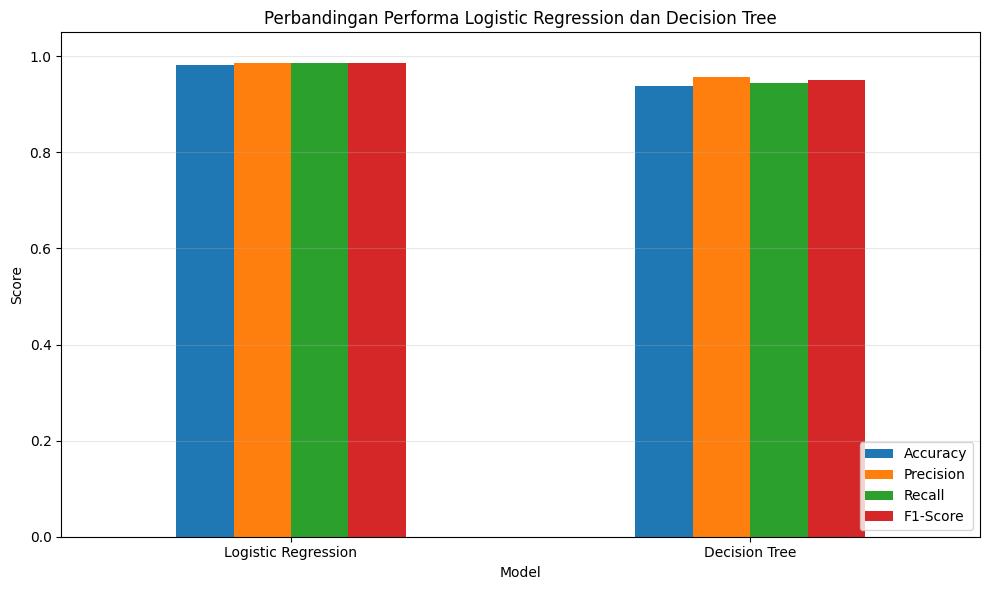

In [21]:
# Grafik perbandingan performa model

comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Performa Logistic Regression dan Decision Tree")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Membandingkan Recall

if recall_log > recall_tree:
    best_model = "Logistic Regression"
    best_recall = recall_log
elif recall_tree > recall_log:
    best_model = "Decision Tree"
    best_recall = recall_tree
else:
    best_model = "Kedua model memiliki Recall yang sama"
    best_recall = recall_log

print("Model dengan Recall tertinggi:", best_model)
print(f"Nilai Recall: {best_recall:.3f}")

Model dengan Recall tertinggi: Logistic Regression
Nilai Recall: 0.986


## Analisis Hasil

Berdasarkan hasil evaluasi, kedua model dibandingkan menggunakan Accuracy, Precision, Recall, dan F1-Score. Perhatian utama diberikan pada nilai **Recall** karena dataset yang digunakan berkaitan dengan diagnosis kanker.

Recall mengukur kemampuan model dalam menemukan seluruh sampel positif yang sebenarnya. Dalam kasus medis, False Negative sangat berisiko karena berarti pasien yang sebenarnya memiliki kondisi kanker dapat diprediksi sebagai bukan kanker. Oleh karena itu, model dengan Recall yang lebih tinggi lebih mampu meminimalkan kemungkinan kasus kanker terlewat.

Accuracy saja tidak cukup untuk menjadi satu-satunya dasar pemilihan model karena Accuracy hanya menunjukkan proporsi seluruh prediksi yang benar. Dalam konteks diagnosis, kesalahan pada kelas tertentu dapat memiliki konsekuensi yang lebih besar dibandingkan kesalahan lainnya.

Berdasarkan nilai Recall pada tabel hasil evaluasi, model [ISI MODEL DENGAN RECALL TERTINGGI] memiliki Recall sebesar [ISI NILAI], sehingga menjadi model yang lebih baik jika prioritas utama adalah mengurangi False Negative.

Meskipun demikian, perbedaan performa kedua model perlu dilihat dari seluruh metrik. Jika selisih Accuracy, Precision, Recall, dan F1-Score relatif kecil, maka dapat dikatakan bahwa performa kedua model tidak berbeda secara signifikan dari sisi metrik evaluasi sederhana. Sebaliknya, jika terdapat selisih yang cukup besar, model dengan performa lebih baik dapat dipertimbangkan berdasarkan tujuan penggunaan.


In [25]:
# Recall khusus untuk kelas Malignant (kelas 0)

recall_malignant_log = recall_score(
    y_test,
    y_pred_log,
    pos_label=0
)

recall_malignant_tree = recall_score(
    y_test,
    y_pred_tree,
    pos_label=0
)

print("Recall Malignant - Logistic Regression:",
      round(recall_malignant_log, 3))

print("Recall Malignant - Decision Tree:",
      round(recall_malignant_tree, 3))


if recall_malignant_log > recall_malignant_tree:
    print("\nLogistic Regression memiliki Recall Malignant lebih tinggi.")
elif recall_malignant_tree > recall_malignant_log:
    print("\nDecision Tree memiliki Recall Malignant lebih tinggi.")
else:
    print("\nKedua model memiliki Recall Malignant yang sama.")

Recall Malignant - Logistic Regression: 0.976
Recall Malignant - Decision Tree: 0.929

Logistic Regression memiliki Recall Malignant lebih tinggi.


In [26]:
# Tabel evaluasi lengkap

evaluation = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_tree
    ],
    "Precision": [
        precision_log,
        precision_tree
    ],
    "Recall Benign": [
        recall_log,
        recall_tree
    ],
    "Recall Malignant": [
        recall_malignant_log,
        recall_malignant_tree
    ],
    "F1-Score": [
        f1_log,
        f1_tree
    ]
})

display(
    evaluation
    .set_index("Model")
    .round(3)
)

,Accuracy,Precision,Recall Benign,Recall Malignant,F1-Score
Model,,,,,
Logistic Regression,0.982,0.986,0.986,0.976,0.986
Decision Tree,0.939,0.958,0.944,0.929,0.951


# Kesimpulan

Pada praktikum ini telah dipelajari penerapan algoritma klasifikasi Logistic Regressiondan Decision Tree menggunakan dataset Breast Cancer Wisconsin. Proses yang dilakukan meliputi pemuatan dataset, Exploratory Data Analysis (EDA), pembagian data menjadi data training dan testing, standardisasi fitur, pelatihan model, serta evaluasi menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

Hasil evaluasi menunjukkan bahwa kedua model mampu melakukan klasifikasi antara kelas Malignant dan Benign dengan performa yang dapat dibandingkan melalui berbagai metrik. Dalam kasus diagnosis kanker, Recall untuk kelas Malignant menjadi perhatian penting karena False Negative dapat menyebabkan kasus kanker tidak terdeteksi oleh model. Oleh karena itu, pemilihan model tidak sebaiknya hanya berdasarkan Accuracy, tetapi juga mempertimbangkan Recall, Precision, dan F1-Score.

Keterbatasan praktikum ini adalah dataset relatif kecil dan model yang digunakan masih menggunakan konfigurasi dasar. Selain itu, hasil model belum dapat dianggap sebagai sistem diagnosis medis nyata karena diperlukan validasi klinis, dataset yang lebih beragam, serta pengujian lebih lanjut sebelum digunakan dalam lingkungan medis.
